{'topic': '猫', 'joke': '**猫的求救**  \n\n一只猫正在疯狂地抓挠客厅的皮沙发。  \n主人怒吼：“你再抓一次试试看！”  \n\n猫停了一下，缓缓举起爪子，竖起中指（猫爪分趾），把沙发挠得更狠了。  \n\n主人震惊：“你居然会竖中指？！”  \n\n猫淡定地舔了舔爪子：“这叫‘抓重点’。”', 'improved_joke': '**猫的求救**  \n\n一只猫正在疯狂地抓挠客厅的皮沙发。  \n主人怒吼：“你再抓一次试试看！”  \n\n猫停了一下，缓缓举起爪子，竖起中指（猫爪分趾），把沙发挠得更狠了。  \n\n主人震惊：“你居然会竖中指？！”  \n\n猫淡定地舔了舔爪子：“这叫‘抓重点’。”  \n\n主人冷笑：“你抓的是重点，我心疼的是‘皮’点——这沙发可是真皮，你再抓，我就让你‘皮’开肉绽。”  \n\n猫瞥了他一眼，又挠了两下：“哦？那正好，我先帮你‘开开眼’——你看这纹路，是不是像极了你昨天签的‘猫粮分期付款’合同？”  \n\n主人愣住：“你连这都懂？”  \n\n猫优雅地甩了甩尾巴：“当然，我可不是‘等闲之辈’——我是‘等粮之辈’。你再不续粮，我就把你这沙发挠成‘流苏款’，让你家客厅直接‘走红毯’。”  \n\n主人崩溃：“你赢了……我这就去买粮，你手下留情！”  \n\n猫满意地收起爪子：“这才叫‘双赢’——你保住了皮，我保住了粮。下次记得，别让我‘指’挥你。”', 'final_joke': '主人拎着猫粮袋子回来时，猫正蹲在沙发上，爪子下面压着一张皱巴巴的纸。  \n它把纸推过来，上面画着歪歪扭扭的曲线，旁边还有几个爪印：“这是沙发皮接下来的‘走势图’，你看这个拐点，预计下周你会主动给我换猫抓板。”  \n主人刚想开口，猫已经翻开手机，屏幕上是“猫语翻译APP”的付费页面：“这个月你绑定的自动续费，是我用你的指纹偷偷开的。现在，要么你答应加餐，要么我直接卸载它——那你就再也听不懂我高贵的威胁了。”  \n主人沉默三秒，掏出工资卡：“你赢了，连科技都站在你那边。”  \n猫这时突然跳下沙发，从角落叼出一只逗猫棒，放在他脚边，语气忽然软了：“其实……我挠沙发，是想让你把逗猫棒从缝隙里拿出来。但后来发现，你连我的‘猫式表达’都学不会，我就只能费点劲，教会你什么叫‘谈判的艺术’。”  \n它蹭了蹭他的裤腿：“所以

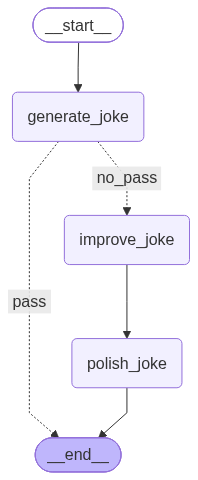

In [1]:

from typing import TypedDict, Literal

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import START, END
from langgraph.graph import StateGraph

load_dotenv(override=True)
# 获取大模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":
            {
                "type": "disabled"
            }
    }
)


# 图状态
class OverAllState(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# 节点
def generate_joke(state: OverAllState) -> OverAllState:
    """第一次调用大模型，生成初始笑话"""

    msg = model.invoke(
        [HumanMessage(content=f"写一个关于{state['topic']}的简短笑话")]
    )

    return {
        "joke": msg.content
    }


def check_punchline(state: OverAllState) -> Literal["pass", "no_pass"]:
    """判断笑话中是否包含包袱"""

    # 简单判断: 小韩找那个是否包含问号或感叹号
    if "?" in state["joke"] or "!" in state["joke"]:
        return "pass"
    return "no_pass"


def improve_joke(state: OverAllState) -> OverAllState:
    """第二次调用大模型，添加通过双关语改进笑话"""

    msg = model.invoke([HumanMessage(content=f"通过添加双关语，让下面这个笑话更有趣: \n{state['joke']}")])
    return {
        "improved_joke": msg.content
    }


def polish_joke(state: OverAllState) -> OverAllState:
    """第三次调用大模型，对笑话进行润色"""

    msg = model.invoke(
        [HumanMessage(content=f"为下面这个笑话添加一个出人意料的反转：\n{state['improved_joke']}")]
    )
    return {"final_joke": msg.content}


# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("generate_joke", generate_joke)
builder.add_node("improve_joke", improve_joke)
builder.add_node("polish_joke", polish_joke)

# 添加边
builder.add_edge(START, "generate_joke")
builder.add_conditional_edges(
    "generate_joke",
    check_punchline,
    {
        "no_pass": "improve_joke",
        "pass": END
    },
)
builder.add_edge("improve_joke", "polish_joke")
builder.add_edge("polish_joke", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
response = graph.invoke({"topic": "猫"})
print(response)

from IPython.display import display

display(graph)